In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
from dotenv import load_dotenv
import pickle

In [2]:
load_dotenv()

True

In [65]:
os.listdir('.')

['.ipynb_checkpoints',
 'Custom_scripts.py',
 'data_exploration.ipynb',
 'model_dev.ipynb',
 'model_dev_collab.ipynb',
 'model_eval.ipynb',
 'pred_labels.pkl',
 'valid_labels.pkl',
 '__pycache__']

**CLASS NAMES PICKLE**

In [4]:
with open('../pickle_items/class_names.pkl','rb') as f:
    class_names = pickle.load(f)

In [5]:
class_names

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [6]:
import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

from PIL import Image

In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [11]:
from Custom_scripts import CustomNN

In [67]:
# constants 
IMAGE_SIZE = (224,224)
BATCH_SIZE = 32

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

**MODEL PTH LOAD**

In [22]:
model = CustomNN(num_classes=len(class_names))
model.to(device)

CustomNN(
  (feature_extract): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (9): ReLU()
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Dropout(p=0.2, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_feat

In [23]:
model.load_state_dict(torch.load('../models/model_v05.pth', map_location=device))

<All keys matched successfully>

In [24]:
model.eval()

CustomNN(
  (feature_extract): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (9): ReLU()
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Dropout(p=0.2, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_feat

**TRANSFORMS FOR VALIDATION AND TEST**

In [19]:
test_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor()
])

valid_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor()
])

In [20]:
valid_dataset = ImageFolder(root="../data/valid",transform=valid_transform)

valid_dataloader = DataLoader(valid_dataset,batch_size=32,shuffle=False)

In [21]:
len(valid_dataset)

17572

**PREDICTION ON VALIDATION SET**

In [64]:
all_preds = []
all_labels = []
all_yscores = []

with torch.no_grad():
    for images , labels in valid_dataloader:
        y_pred = model(images)

        _,predicted = torch.max(y_pred, axis=1)

        all_preds.extend(predicted)
        all_labels.extend(labels)
        all_yscores.extend(_)

In [69]:
len(all_yscores)

17572

In [55]:
len(all_preds)

17572

**VALIDATION METRICS**

In [56]:
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9610
Precision: 0.9626
Recall   : 0.9610
F1 Score : 0.9604


In [46]:
with open('valid_labels.pkl','wb') as f:
    pickle.dump(all_labels,f)
with open('pred_labels.pkl','wb') as f:
    pickle.dump(all_preds,f)

In [47]:
print(classification_report(all_labels, all_preds, target_names=class_names))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.94      0.96       504
                                 Apple___Black_rot       0.94      0.99      0.96       497
                          Apple___Cedar_apple_rust       0.97      1.00      0.98       440
                                   Apple___healthy       0.94      0.97      0.96       502
                               Blueberry___healthy       0.96      0.99      0.98       454
          Cherry_(including_sour)___Powdery_mildew       1.00      0.98      0.99       421
                 Cherry_(including_sour)___healthy       0.91      1.00      0.95       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       1.00      0.80      0.89       410
                       Corn_(maize)___Common_rust_       0.99      0.99      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.85      1.00      0.

**PER CLASS ACCURACY**

In [50]:
confusion_mat = confusion_matrix(all_labels, all_preds)

In [54]:
confusion_mat.diagonal()/confusion_mat.sum(axis=1)

array([0.94246032, 0.98792757, 0.99772727, 0.97211155, 0.99339207,
       0.98099762, 1.        , 0.79756098, 0.99371069, 0.99580713,
       1.        , 0.99364407, 0.95833333, 0.98837209, 0.99527187,
       0.98807157, 0.96296296, 0.98611111, 0.98953975, 0.96579477,
       1.        , 0.91340206, 0.95614035, 0.98426966, 0.95049505,
       1.        , 0.99774775, 0.99780702, 0.94117647, 0.89375   ,
       0.68682505, 0.98297872, 0.88073394, 0.95632184, 0.91247265,
       0.97142857, 0.99776786, 0.99168399])

<Axes: >

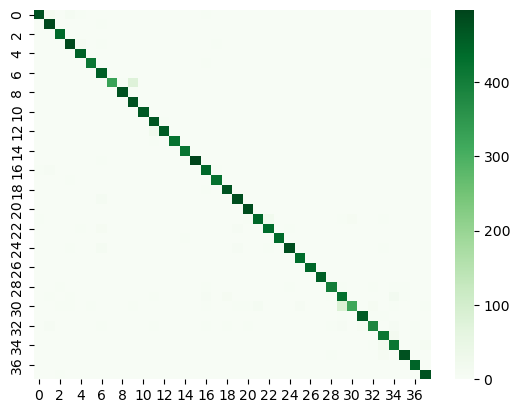

In [90]:
sns.heatmap(confusion_mat, cmap='Greens')

In [59]:
per_class_accuracy = confusion_mat.diagonal()/confusion_mat.sum(axis=1)

for class_name, acc in zip(class_names, per_class_accuracy):
    print(f'{class_name:50} : Accuracy {acc:.4f}')

Apple___Apple_scab                                 : Accuracy 0.9425
Apple___Black_rot                                  : Accuracy 0.9879
Apple___Cedar_apple_rust                           : Accuracy 0.9977
Apple___healthy                                    : Accuracy 0.9721
Blueberry___healthy                                : Accuracy 0.9934
Cherry_(including_sour)___Powdery_mildew           : Accuracy 0.9810
Cherry_(including_sour)___healthy                  : Accuracy 1.0000
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot : Accuracy 0.7976
Corn_(maize)___Common_rust_                        : Accuracy 0.9937
Corn_(maize)___Northern_Leaf_Blight                : Accuracy 0.9958
Corn_(maize)___healthy                             : Accuracy 1.0000
Grape___Black_rot                                  : Accuracy 0.9936
Grape___Esca_(Black_Measles)                       : Accuracy 0.9583
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)         : Accuracy 0.9884
Grape___healthy                   

In [104]:
with open('per_class_acc_cnn.pkl','wb') as f:
    pickle.dump(per_class_accuracy,f)

**MIS-CLASSIFIED IMAGES, ACCURACY, LABELS**

In [60]:
misclassified = []

with torch.no_grad():

    for images, labels in valid_dataloader:
        
        y_pred = model(images)
        _, predicted = torch.max(y_pred, 1)

        for img, true, pred in zip(images, labels, predicted):
            if true != pred:
                misclassified.append((
                    img,
                    true.item(),
                    pred.item()
                ))

In [61]:
len(misclassified)

685

In [63]:
1-len(misclassified)/len(valid_dataset)

0.9610175278852721

In [74]:
misclassified[0][0].shape

torch.Size([3, 224, 224])

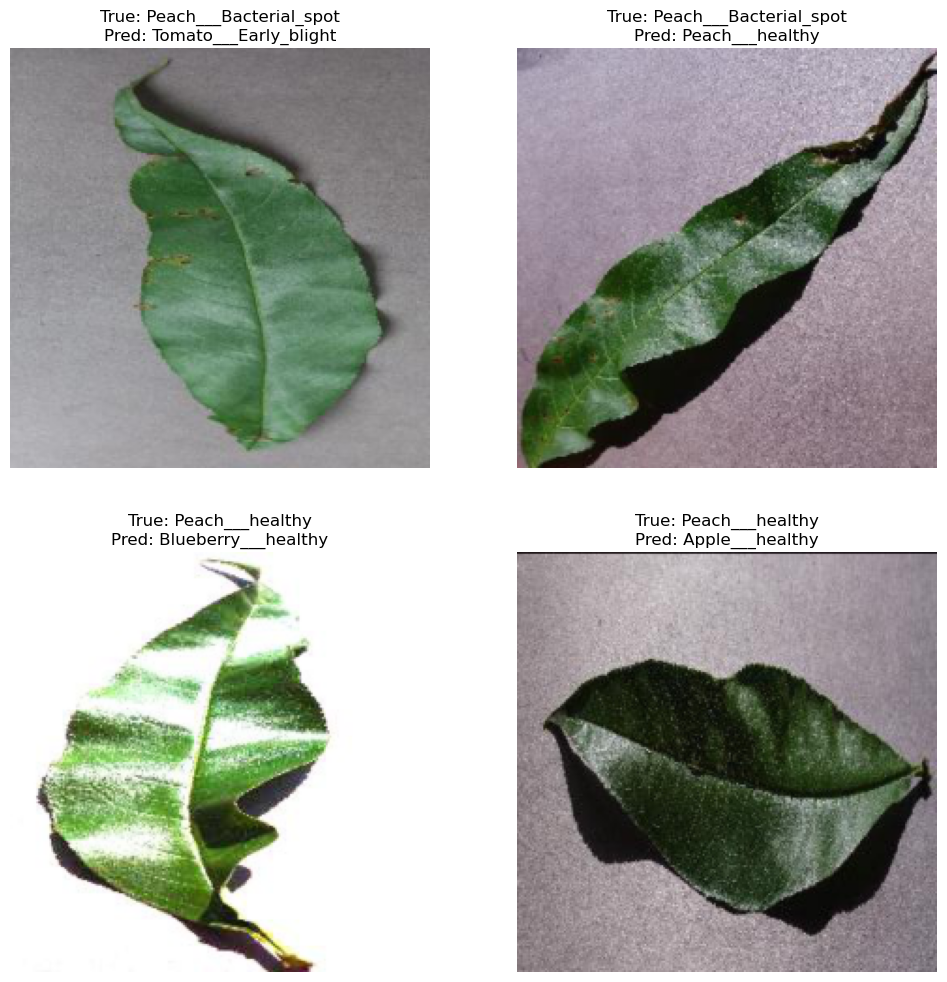

In [78]:
plt.figure(figsize=(12, 12))

for i in range(4):

    img, true, pred = misclassified[i+200]
    plt.subplot(2,2, i + 1)
    plt.imshow(img.permute(1, 2, 0))
    plt.title(f"True: {class_names[true]}\nPred: {class_names[pred]}")
    plt.axis("off")

plt.show()

In [91]:
with open('../pickle_items/train_losses.pkl','rb') as f:
    train_losses = pickle.load(f)
with open('../pickle_items/train_accs.pkl','rb') as f:
    train_accs = pickle.load(f)
with open('../pickle_items/valid_accs.pkl','rb') as f:
    valid_accs = pickle.load(f)
with open('../pickle_items/valid_losses.pkl','rb') as f:
    valid_losses = pickle.load(f)

In [92]:
len(train_accs)

30

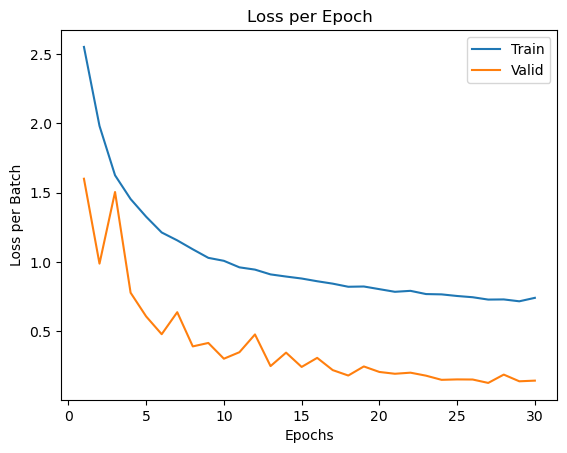

In [102]:
plt.plot(range(1,31),train_losses, label='Train')
plt.plot(range(1,31),valid_losses, label='Valid')
plt.title('Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss per Batch')
plt.legend()

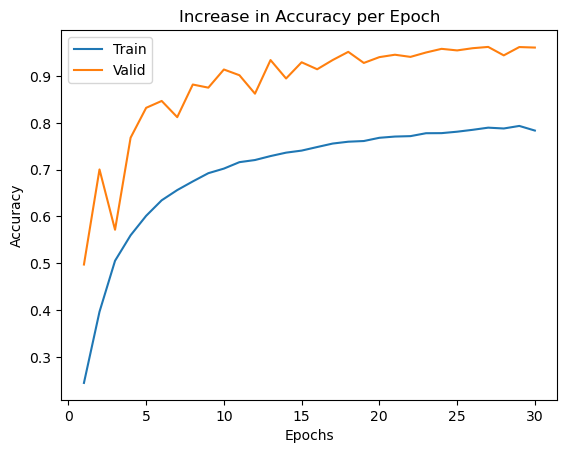

In [103]:
plt.plot(range(1,31),train_accs, label='Train')
plt.plot(range(1,31),valid_accs, label='Valid')
plt.title('Increase in Accuracy per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

**TESTING FOR SINGLE IMAGE INPUT**

In [14]:
TEST_DIR = os.getenv('test_folder')

In [49]:
image_name = os.listdir(os.path.join(TEST_DIR, os.listdir(TEST_DIR)[0]))[0]
image_name

'AppleCedarRust1.JPG'

In [37]:
image_path = os.path.join(os.path.join(TEST_DIR, os.listdir(TEST_DIR)[0]), image_name)

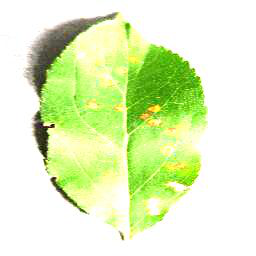

In [39]:
image = Image.open(image_path)
image

In [46]:
transformed_image = test_transform(image)
transformed_image.shape

torch.Size([3, 224, 224])

In [47]:
y_pred = model(transformed_image.unsqueeze(0))

In [48]:
_,predicted = torch.max(y_pred,axis=1)
class_names[predicted]

'Apple___Cedar_apple_rust'